# Week 1 — The Zoo of Ocean Waves

**OE 754 / 854 — Ocean Waves & Tides**

Ocean surface waves span *six orders of magnitude* in period, from millimeter capillaries ($T \sim 0.01\,$s) to tides ($T \sim 12\,$h). A single theoretical framework won't cover that range, but the classification by **period** is the organizing axis that lets us know which framework applies where.

This notebook:

1. Draws a schematic energy-density-vs-period spectrum in the style of Kinsman / D&D Fig. 1.2, with the named bands labeled.
2. Computes the depth regime $h/L$ for several canonical sea states at a few typical water depths, so you can see which waves are in deep / intermediate / shallow water *at the same place*.
3. Demonstrates dispersion — waves of different periods sort themselves out — by propagating a sum of two swell components.

There's no problem set yet this week, but these plots foreshadow Weeks 4, 5, and 6.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import figure_style as fs

g = 9.81

## 1. The period spectrum

Most of the ocean's surface-wave energy sits in the wind-wave / swell band, $T \sim 1$–$25\,$s. There's a sharp secondary peak near $T \sim 12\,$h from the tides, a modest hump at the infragravity / long-wave periods in between, and a tail of capillary noise at sub-second periods. Sketched on log-period axes:


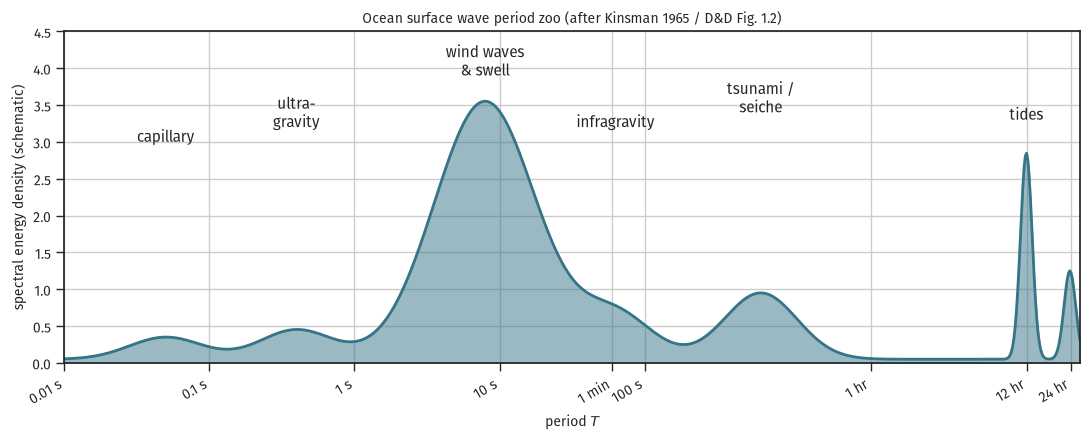

In [2]:
# Schematic spectrum: Gaussians on a log-T axis, loosely placed and sized
# to match the energy partition in real wave records.
logT = np.linspace(-2, 5, 800)  # log10(T in seconds); -2 to 5 covers 0.01 s to 1e5 s (~28 hr)

def gauss(logT, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((logT - mu) / sigma) ** 2)

spectrum = (
      gauss(logT, mu=-1.3, sigma=0.25, amp=0.3)   # capillary (~0.05 s)
    + gauss(logT, mu=-0.4, sigma=0.25, amp=0.4)   # ultra-gravity (~0.4 s)
    + gauss(logT, mu=0.9,  sigma=0.35, amp=3.5)   # wind waves & swell (~8 s)
    + gauss(logT, mu=1.8,  sigma=0.25, amp=0.6)   # infragravity
    + gauss(logT, mu=2.8,  sigma=0.25, amp=0.9)   # tsunami/seiche
    + gauss(logT, mu=4.63, sigma=0.04, amp=2.8)   # semidiurnal tide (~12.4 h)
    + gauss(logT, mu=4.93, sigma=0.04, amp=1.2)   # diurnal tide (~24 h)
    + 0.05  # floor
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(logT, 0, spectrum, color=fs.color_list[1], alpha=0.5)
ax.plot(logT, spectrum, lw=2, color=fs.color_list[1])

# band labels with faint guide lines
bands = [
    (-1.3, 3.0,  'capillary'),
    (-0.4, 3.2,  'ultra-\ngravity'),
    ( 0.9, 3.9,  'wind waves\n& swell'),
    ( 1.8, 3.2,  'infragravity'),
    ( 2.8, 3.4,  'tsunami /\nseiche'),
    ( 4.63, 3.3, 'tides'),
]
for x, y, lbl in bands:
    ax.text(x, y, lbl, ha='center', fontsize=11)

# Decade ticks labeled as familiar times
tick_locs = [-2, -1, 0, 1, 2, np.log10(60), np.log10(3600), np.log10(12*3600), np.log10(24*3600)]
tick_labs = ['0.01 s', '0.1 s', '1 s', '10 s', '100 s', '1 min', '1 hr', '12 hr', '24 hr']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, rotation=30, ha='right')
ax.set_xlabel('period $T$')
ax.set_ylabel('spectral energy density (schematic)')
ax.set_title('Ocean surface wave period zoo (after Kinsman 1965 / D&D Fig. 1.2)')
ax.set_xlim(logT[0], logT[-1])
ax.set_ylim(0, 4.5)
plt.tight_layout()
plt.show()

Takeaway: **most of this course is about the tall peak in the middle** (wind waves + swell). **Week 11 is about the tall spike on the right** (tides). The other bands are real but secondary.

## 2. The same wave, different depths — regime classification

Period alone doesn't tell you whether a wave is in deep, shallow, or intermediate water — that depends on the local depth $h$ through the ratio $h/L$. The same 10-second swell is *deep* offshore and *shallow* at the beach.

Tabulate $kh$ and the regime for a handful of canonical waves at three sites (offshore, shelf, surf zone):


In [3]:
def solve_k(omega, h, tol=1e-12):
    k = omega**2 / g
    for _ in range(50):
        tkh = np.tanh(k * h)
        f = omega**2 - g * k * tkh
        fp = -g * tkh - g * h * k * (1 - tkh**2)
        dk = f / fp
        k -= dk
        if abs(dk) < tol:
            break
    return k

def regime(kh):
    if kh > np.pi:       return 'deep'
    if kh < np.pi / 10:  return 'shallow'
    return 'intermediate'


waves = [
    ('Wind chop',   2.0),   # T = 2 s
    ('Wind wave',   6.0),
    ('Local swell', 10.0),
    ('Long swell',  16.0),
    ('Tsunami',     600.0),
]
depths = [3000.0, 30.0, 3.0]

# Header
print(f'{"":>14s}', end='')
for h in depths:
    print(f'   h = {h:>7.1f} m', end='')
print()
print(f'{"":>14s}', end='')
for _ in depths:
    print(f'   kh  |  regime  ', end='')
print()
print('-' * 74)

for name, T in waves:
    omega = 2 * np.pi / T
    print(f'{name:>14s}', end='')
    for h in depths:
        k = solve_k(omega, h)
        kh = k * h
        print(f'   {kh:5.2f}  |  {regime(kh):>8s} ', end='')
    print()

                 h =  3000.0 m   h =    30.0 m   h =     3.0 m
                 kh  |  regime     kh  |  regime     kh  |  regime  
--------------------------------------------------------------------------
     Wind chop   3018.23  |      deep    30.18  |      deep     3.03  |  intermediate 
     Wind wave   335.36  |      deep     3.36  |      deep     0.61  |  intermediate 
   Local swell   120.73  |      deep     1.37  |  intermediate     0.35  |  intermediate 
    Long swell   47.16  |      deep     0.75  |  intermediate     0.22  |   shallow 
       Tsunami    0.18  |   shallow     0.02  |   shallow     0.01  |   shallow 


You can read the columns of that table as a rule of thumb: **offshore swell is deep-water; at the shelf, most waves are intermediate; in the surf zone, everything is shallow.** A tsunami is the odd one out — it's *always* shallow because its wavelength is enormous.

## 3. Dispersion visualized: two swell components drifting apart

Deep-water dispersion says $C = gT/(2\pi)$: longer waves move faster. A pulse that starts as many frequencies superposed will, after enough time, sort itself into a ranked train with the longest periods leading.

Simulate a 10-second swell and a 16-second swell launched together as a localized packet in deep water. Energy travels at the group speed $C_g = C/2$, so after time $t$ the two packets should be separated by $|C_{g,1} - C_{g,2}|\,t$:


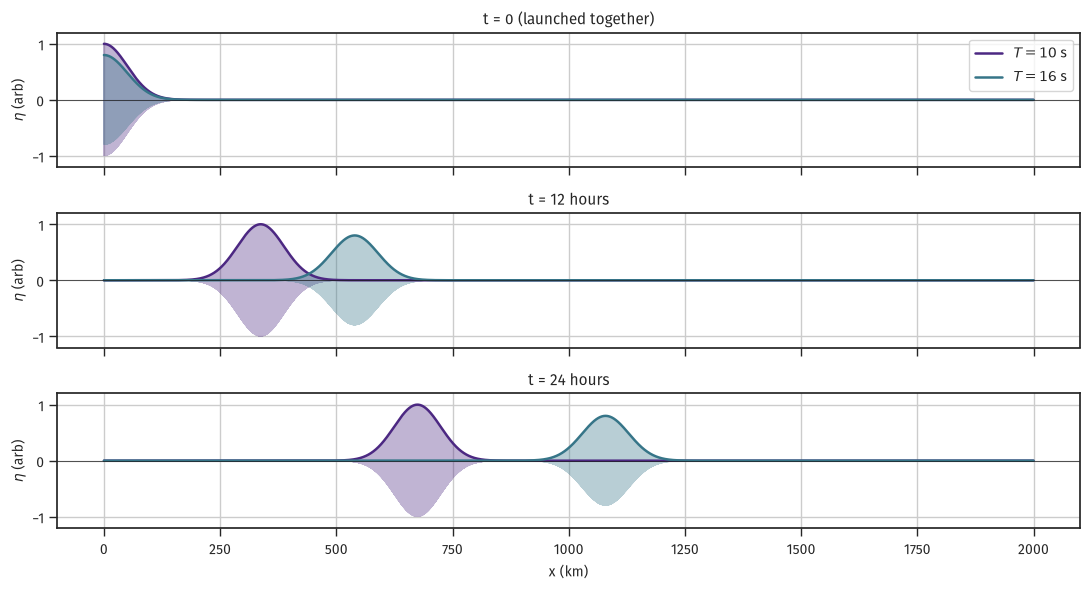

T = 10.0 s :  L =  156.1 m,  C = 15.61 m/s,  Cg =  7.81 m/s
T = 16.0 s :  L =  399.7 m,  C = 24.98 m/s,  Cg = 12.49 m/s
separation after 24 h = 405 km


In [4]:
h = 4000.0   # deep
# Resolve the carrier: the 10 s wave has L = gT^2/(2 pi) ~ 156 m, so dx must be
# a small fraction of that. 2000 km at dx = 10 m.
x = np.arange(0.0, 2000e3, 10.0)

# Two narrow Gaussian packets in period, peaks at T = 10 and 16 s
def deep_water_C(T):
    return g * T / (2 * np.pi)

# Each packet has a Gaussian envelope of frequencies around the peak
# and propagates at the group velocity = C/2 in deep water.
def packet(x, t, T0, envelope_width_km=50.0):
    # Simple packet: Gaussian envelope around C_g * t, carrier at T0.
    Cg = deep_water_C(T0) / 2
    center = Cg * t
    envelope = np.exp(-0.5 * ((x - center) / (envelope_width_km * 1e3))**2)
    k = (2 * np.pi / T0)**2 / g   # deep water
    carrier = np.cos(k * (x - center))
    return envelope * carrier, envelope

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
times = [0, 12 * 3600, 24 * 3600]  # t = 0, 12 hr, 24 hr
titles = ['t = 0 (launched together)', 't = 12 hours', 't = 24 hours']

for ax, t, title in zip(axes, times, titles):
    eta1, env1 = packet(x, t, T0=10.0)
    eta2, env2 = packet(x, t, T0=16.0)
    eta2, env2 = 0.8*eta2, 0.8*env2
    # Carrier drawn faintly (many wavelengths per pixel at this scale);
    # the envelope is what carries the lesson.
    ax.plot(x / 1e3, eta1, lw=0.5, alpha=0.35, color=fs.color_list[0])
    ax.plot(x / 1e3, eta2, lw=0.5, alpha=0.35, color=fs.color_list[1])
    ax.plot(x / 1e3, env1, lw=1.8, color=fs.color_list[0], label='$T = 10$ s')
    ax.plot(x / 1e3, env2, lw=1.8, color=fs.color_list[1], label='$T = 16$ s')
    ax.set_ylabel(r'$\eta$ (arb)')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='k', lw=0.5)
    if t == 0:
        ax.legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('x (km)')
plt.tight_layout()
plt.show()

for T0 in (10.0, 16.0):
    print(f'T = {T0:4.1f} s :  L = {g*T0**2/(2*np.pi):6.1f} m,  C = {deep_water_C(T0):5.2f} m/s,'
          f'  Cg = {deep_water_C(T0)/2:5.2f} m/s')
sep = (deep_water_C(16.0) - deep_water_C(10.0)) / 2 * 24 * 3600
print(f'separation after 24 h = {sep/1e3:.0f} km')


The 16-second swell pulls ahead. Its deep-water group speed is $gT/(4\pi) \approx 12.5\,$m/s, compared to $\approx 7.8\,$m/s for the 10-second swell — so after 24 hours the gap is about $(12.5 - 7.8) \times 86400 / 1000 \approx 405\,$km. That separation is **why a distant storm's signature arrives on a far coast as a ranked train of periods** — a phenomenon routinely used to reverse-engineer storm tracks from buoy records.

## 4. Why we spend nine weeks on linear theory

The full water-wave boundary-value problem is nonlinear. Week 4 shows that, for most waves of engineering interest, the nonlinear terms are smaller than the linear ones by a factor of $ka$ — the *wave steepness*. For a typical swell ($H = 2\,$m, $L = 150\,$m), $ka \sim \pi H/L \approx 0.04$. Four percent nonlinear.

Quantify this scale for a range of real wave conditions:


In [5]:
# Compute ka for common wave conditions, comparing typical swell vs near-breaking
cases = [
    ('Typical swell',      2.0, 150.0),
    ('Moderate storm',     4.0, 120.0),
    ('Severe storm',       8.0, 200.0),
    ('Lab wave (steep)',   0.4,   4.0),
    ('Near-breaking',     12.0,  85.0),
]
print(f'{"Case":<22s}{"H (m)":>7s}{"L (m)":>8s}{"ka = πH/L":>14s}{"regime":>22s}')
print('-' * 73)
for name, H, L in cases:
    ka = np.pi * H / L
    if ka < 0.05:
        note = 'linear fine'
    elif ka < 0.15:
        note = 'Stokes corrections'
    elif ka < 0.3:
        note = 'Stokes / stream fn'
    else:
        note = 'near/over breaking'
    print(f'{name:<22s}{H:>7.1f}{L:>8.1f}{ka:>14.3f}{note:>22s}')

Case                    H (m)   L (m)     ka = πH/L                regime
-------------------------------------------------------------------------
Typical swell             2.0   150.0         0.042           linear fine
Moderate storm            4.0   120.0         0.105    Stokes corrections
Severe storm              8.0   200.0         0.126    Stokes corrections
Lab wave (steep)          0.4     4.0         0.314    near/over breaking
Near-breaking            12.0    85.0         0.444    near/over breaking


Most engineering waves live in the $ka < 0.15$ regime where linear theory is either fine outright or needs a Stokes correction. Only at the extreme (near-breaking design waves, lab waves deliberately pushed) does fully-nonlinear theory become necessary. **That's why weeks 3–7 build linear theory first: it covers 90% of the real-world cases.**

## 5. Quick exercises

1. From the period-vs-depth table, pick one wave where the column changes regime between $h = 3000\,$m and $h = 3\,$m. What happens to $L$? To $C$? Does the dispersion relation need a numerical solve, or does the deep-water shortcut suffice at 3000 m?

2. The $T = 2\,$s wind chop lands at $kh = 3.03$ in $h = 3\,$m — the table calls it *intermediate*, but only just: the deep-water cutoff is $kh = \pi \approx 3.14$. Confirm numerically that $h/L$ is a shade under $1/2$, then evaluate $\tanh kh$ at $kh = 3.03$ and decide whether the deep-water shortcut $C = gT/(2\pi)$ actually costs you anything here. Finally: how shallow does the water have to get before that 2-s chop is genuinely *shallow-water* ($kh < \pi/10$)? The answer is smaller than you expect, and it explains why chop keeps its deep-water character right up to the swash.

3. A storm $2000\,$km offshore generates a broad swell spectrum. Using deep-water dispersion, how long does it take for the $T = 20$ s components to arrive? The $T = 10$ s? The $T = 5$ s? (This is how beach-based observers reverse-engineer the *distance* to the storm.)

## Looking ahead

Week 2 starts the fluid mechanics review. Brush off your vector calculus — gradients, divergences, curls, and the material derivative are about to become the daily vocabulary.
